In [1]:
# CODE CELL 1: Imports and Data Loading (Togo)

# Imports: Ensure all libraries are imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the data - NOTE the updated file path!
file_path = 'data/togo-dapaong_qc.csv' 
df = pd.read_csv(file_path)

# Proactive Fix: Flatten column names (if necessary, though less common with 'qc' files)
df.columns = [''.join(col) if isinstance(col, tuple) else col for col in df.columns]

# Convert Timestamp and set as index for Time Series Analysis
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True) 

print(f"Togo Data Loaded. Shape: {df.shape}")

Togo Data Loaded. Shape: (525600, 18)


In [2]:
# CODE CELL 2: Initial Inspection & Missing Value Report (KPI 1)

# Initial inspection
print("Data Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types (info):")
df.info()

# Missing Value Report (KPI 1)
missing_report = df.isna().sum().sort_values(ascending=False)
print("\nMissing Value Count per Column (KPI 1):")
print(missing_report)

Data Shape: (525600, 18)

First 5 Rows:
                     GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
Timestamp                                                                 
2021-10-25 00:01:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.5  0.9     1.1   
2021-10-25 00:02:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.1     1.6   
2021-10-25 00:03:00 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.2     1.4   
2021-10-25 00:04:00 -1.2  0.0  0.0   0.0   0.0  24.8  94.3  1.2     1.6   
2021-10-25 00:05:00 -1.2  0.0  0.0   0.0   0.0  24.8  94.0  1.3     1.6   

                     WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  \
Timestamp                                                                    
2021-10-25 00:01:00      0.4  227.6      1.1  977         0            0.0   
2021-10-25 00:02:00      0.4  229.3      0.7  977         0            0.0   
2021-10-25 00:03:00      0.3  228.5      2.9  977         0            0.0   
2021-10-25 00:04:00      0.3  229.1      4.6

In [3]:
# CODE CELL 3: Summary Statistics (KPI 2)

# Select key numerical columns for the report
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'BP']

# Summary Statistics (KPI 2)
print("Summary Statistics for Key Columns (KPI 2):")
print(df[key_cols].describe())

Summary Statistics for Key Columns (KPI 2):
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      230.555040     151.258469     116.444352     226.144375   
std       322.532347     250.956962     156.520714     317.346938   
min       -12.700000       0.000000       0.000000       0.000000   
25%        -2.200000       0.000000       0.000000       0.000000   
50%         2.100000       0.000000       2.500000       4.400000   
75%       442.400000     246.400000     215.700000     422.525000   
max      1424.000000    1004.500000     805.700000    1380.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      219.568588      27.751788      55.013160       2.368093   
std       307.932510       4.758023      28.778732       1.462668   
min         0.000000      14.900000       3.300000       0

In [5]:
# CODE CELL 4: Drop Columns & Filter Negative Outliers (fixed)
# 1. DROP UNNECESSARY COLUMNS
df.drop(columns=['Comments', 'TModA', 'TModB'], inplace=True, errors='ignore')
print("Dropped entirely missing/unnecessary columns.")

# 2. REMOVE IMPOSSIBLE NEGATIVE IRRADIANCE VALUES (robust / safe)
irradiance_cols = ['GHI', 'DNI', 'DHI']
present_irr = [c for c in irradiance_cols if c in df.columns]

if present_irr:
    # ensure numeric (coerce non-numeric to NaN), count negatives, then clip
    df[present_irr] = df[present_irr].apply(pd.to_numeric, errors='coerce')
    neg_count_before = (df[present_irr] < 0).sum().sum()
    df[present_irr] = df[present_irr].clip(lower=0)
    neg_count_after = (df[present_irr] < 0).sum().sum()
    print(f"Replaced {int(neg_count_before)} negative irradiance values with 0 (remaining negatives: {int(neg_count_after)}).")
else:
    print(f"No irradiance columns found among {irradiance_cols}; skipped negative-value fix.")

# 3. FILTER DAYTIME ZEROS (only if GHI exists and index is datetime)
if 'GHI' in df.columns:
    # ensure DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors='coerce')
    # Remove corrupted readings where GHI == 0 during expected daylight hours
    df_filtered = df[(df['GHI'] > 0) | (df.index.hour < 6) | (df.index.hour > 18)].copy()
    print(f"Dataframe size reduced from {len(df)} to {len(df_filtered)} after filtering daytime zeros.")
else:
    df_filtered = df.copy()
    print("GHI column not present; skipped daytime-zero filtering.")

Dropped entirely missing/unnecessary columns.
Replaced 257385 negative irradiance values with 0 (remaining negatives: 0).
Dataframe size reduced from 525600 to 503393 after filtering daytime zeros.


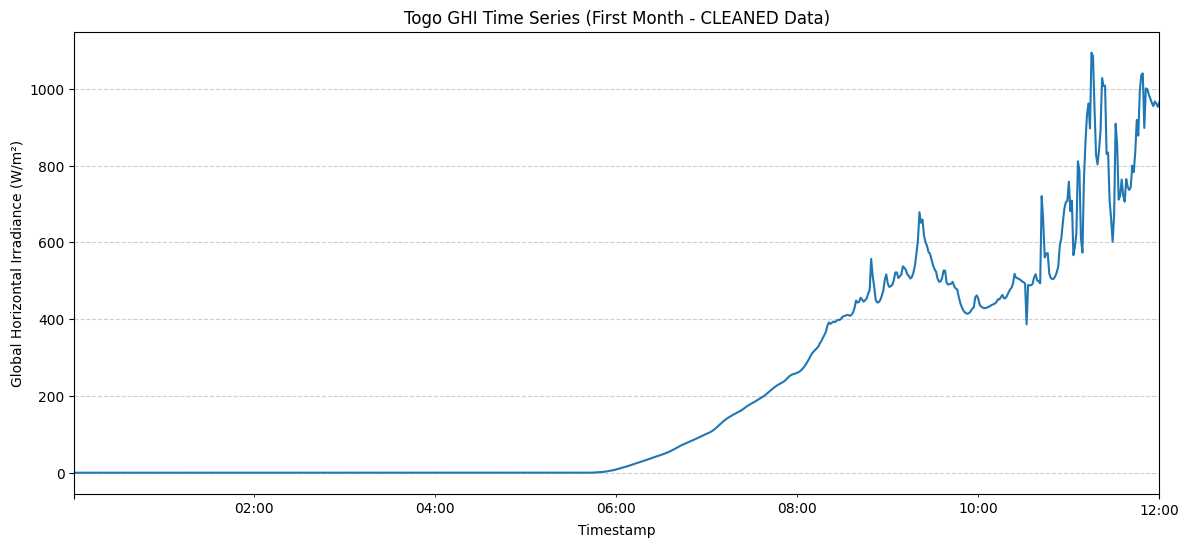

In [6]:
# CODE CELL 5: Time Series Plot (GHI)

# Plotting GHI for a sample period (the first 30 days) from the CLEANED data
plt.figure(figsize=(14, 6))
df_filtered['GHI'].head(24 * 30).plot(title='Togo GHI Time Series (First Month - CLEANED Data)')
plt.ylabel('Global Horizontal Irradiance (W/m²)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

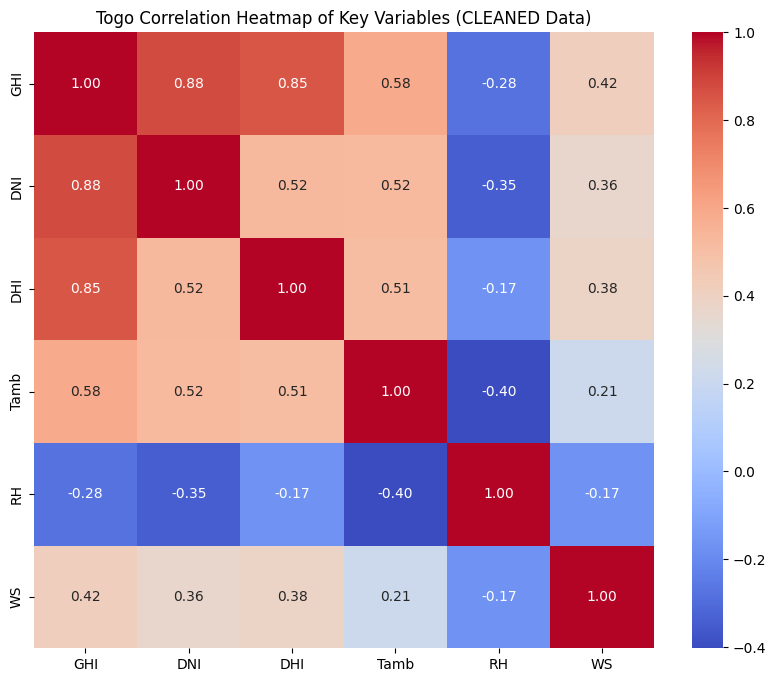

In [7]:
# CODE CELL 6: Correlation Heatmap

# Select variables for correlation (using the cleaned df_filtered)
correlation_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'WS']

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_filtered[correlation_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Togo Correlation Heatmap of Key Variables (CLEANED Data)')
plt.show()

In [8]:
# CODE CELL 7: Feature Engineering

df_model = df_filtered.copy()

# Time-Based Features (Cyclic Transformations)
df_model['hour'] = df_model.index.hour
df_model['dayofyear'] = df_model.index.dayofyear
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24)
df_model['day_sin'] = np.sin(2 * np.pi * df_model['dayofyear'] / 365)
df_model['day_cos'] = np.cos(2 * np.pi * df_model['dayofyear'] / 365)
df_model.drop(columns=['hour', 'dayofyear'], inplace=True)

# Lag Features (12 lags = 1 hour back, since data is 5-minute resolution)
TARGET = 'GHI'
LAG = 12 
for i in range(1, LAG + 1):
    df_model[f'{TARGET}_Lag_{i}'] = df_model[TARGET].shift(i)

df_model.dropna(inplace=True)
print("Feature Engineering complete.")
print("Final modeling DataFrame shape:", df_model.shape)

Feature Engineering complete.
Final modeling DataFrame shape: (503381, 31)


Model Evaluation (KPIs) for Togo:
Mean Squared Error (MSE): 1585.16
R-squared Score (R2): 0.9829


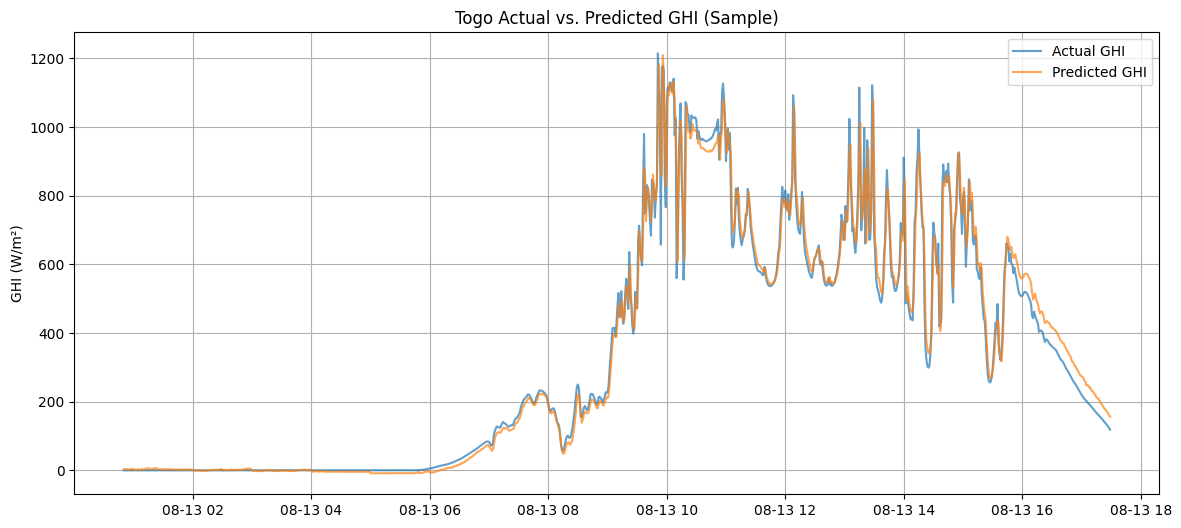

In [10]:
# CODE CELL 8: Modeling, Prediction, and Evaluation (fixed)
# Ensure TARGET is defined
TARGET = 'GHI'

# Target
y = df_model[TARGET].copy()

# Safe list of columns to remove if present
optional_drop = ['ModA', 'ModB', 'WSdev', 'WDSdev', 'Cleaning', 'Precipitation']

# Build X by dropping the target and any optional columns that exist, then keep numeric columns only
cols_to_drop = [TARGET] + [c for c in optional_drop if c in df_model.columns]
X = df_model.drop(columns=cols_to_drop, errors='ignore')
X = X.select_dtypes(include=[np.number]).copy()

# Align X and y (drop any residual NaNs)
common_idx = X.index.intersection(y.index)
X = X.loc[common_idx].dropna()
y = y.loc[X.index]

# Time Series Split (80/20 chronological split)
split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation (KPIs for Task 3)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation (KPIs) for Togo:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

# Visualization of Actual vs. Predicted (Sample)
plt.figure(figsize=(14, 6))
sample_size = min(1000, len(y_test))
plt.plot(y_test.index[:sample_size], y_test[:sample_size], label='Actual GHI', alpha=0.7)
plt.plot(y_test.index[:sample_size], y_pred[:sample_size], label='Predicted GHI', alpha=0.7)
plt.title('Togo Actual vs. Predicted GHI (Sample)')
plt.ylabel('GHI (W/m²)')
plt.legend()
plt.grid(True)
plt.show()